# Imports and load in NATSAL 3 datafile

In [106]:
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import pyreadstat

from tqdm import tqdm

In [107]:
# Read the .sav file
df, meta = pyreadstat.read_sav('UKDA-7799-spss/spss/spss19/eul_natsal_2010_for_archive.sav')
meta = vars(meta)

meta

{'column_names': ['sin2',
  'dateyoi',
  'total_wt',
  'psu_scrm',
  'strata',
  'stratagrp',
  'stratagrp2',
  'stratagrp3',
  'dage',
  'dagegr',
  'agrp',
  'agrp2',
  'rdoby',
  'birthcohort',
  'rsex',
  'health',
  'disabil',
  'limit',
  'disabil2',
  'medcona',
  'medwcha1',
  'medwcha2',
  'medwcha3',
  'medwcha4',
  'medwcha5',
  'medwcha6',
  'medwcha7',
  'medwcha8',
  'medwcha9',
  'drgheart',
  'drghyp',
  'drgins',
  'drgdi',
  'drgpark',
  'drgepil',
  'medconb',
  'medwchb1',
  'medwchb2',
  'medwchb3',
  'medwchb4',
  'medwchb5',
  'medwchb6',
  'medwchb7',
  'medwchb8',
  'drgpros',
  'medconc',
  'medwchc1',
  'medwchc2',
  'medwchc3',
  'medwchc4',
  'medwchc5',
  'medwchc6',
  'medwchc7',
  'whnhystgpd',
  'medcond',
  'medwchd1',
  'medwchd2',
  'medwchd3',
  'medwchd4',
  'medwchd5',
  'medwchd6',
  'medwchd7',
  'medwchd8',
  'medwchd9',
  'medwchd10',
  'drgdep',
  'drgmh',
  'hefunc',
  'heatt1',
  'heatt2',
  'heatt3',
  'heatt4',
  'heatt5',
  'heatt6',
  '

In [108]:
#15 162 adults in the survey - that is the length of this dataframe.

The files 'eul_natsal_2010_for_archive_ukda_data_dictionary.rtf' and '7799_natsal_3_codebook.pdf' are useful to me for understanding the data

Columns that matter to me:
- 'dage' : respondant's age in years
- 'total_wt': this column gives the weighting to give each row when calculating things like averages, so that we don't end up with a biased sample}
-  'zmodefexp': this column tells us the interview mode, which is important for age of sexual debut as if the interview mode was not private enough we may have a biased result (in which case remove the 'not private enough' options, as in the data dictionary: eul_natsal_2010_for_archive_ukda_data_dictionary.rtf)
- 'het': whether the respondant has had heterosexual sex since age 13 (needed to count the 0s that have not had sex by the time of the survey, assuming no sex before 13 )
    - 'everhet' seems similar, but 'het' is marked as a summary variable so probs is the one we really care for?
- 'afsexall': age at first heterosexual sexual experience. 
    - 96 = not happened yet; 97 = refused; 99=not answered
- 'rsex': the sex of the respondant
    - -8:don't know, 1=male, 2=female, -1=n/a, -9=refusal
- 'partnerhh' : whether or not respondant lives with spouse/cohabiting partner
    - 0:no (does not live with partner), 1: yes (does live with a partner)
- 'hhpartage': age of spouse/civil partner/cohabiting partner
    - -1:not applicable (presumably this means there is no such partner), 999:not answered


# Working on mixing matrices

We populate a mixing matrix by going over each row and, if the individual currently has a cohabiting partner, we add 1 to the number of individuals with a cohabiting partner and 1 to the relevant maleage-femaleage box in a grid (based on sex of this partner, assuming the relationship is heterosexual, and the age of the cohabiting partner). We assume no partnerships occur within the dataset itself (or that the rate of them is uniform random such that it does not bias our rate calculations) and then estimate 'married' mixing matrix

In [109]:
age_bins = list(range(0,76,5)) #defines the lower bounds of each age

mixing_matrix = np.zeros((len(age_bins), len(age_bins)))

for index, row in tqdm(df.iterrows()):
    sex = row['rsex']
    age = row['dage']
    cohabitorage = row['hhpartage']
    weight = row['total_wt']
    if sex in [1,2] and 0<age<90 and 0<cohabitorage<150: #ensure we only count 'valid' responses, including discarding 'none' encodings
        self_bin = np.searchsorted(age_bins, age, side='right') - 1
        cohabitor_bin = np.searchsorted(age_bins, cohabitorage, side='right') - 1
        if sex==1: #1==male; mixing matrix defines female in rows, male in columns
            mixing_matrix[cohabitor_bin, self_bin] += weight
        else: #in this case, sex is female; mixing matrix has female in rows, male in columns
            mixing_matrix[self_bin, cohabitor_bin] += weight

#Normalise mixing matrix row-wise to get distributions of male ages preferred by female agents in each age bin
mixing_matrix = mixing_matrix / mixing_matrix.sum(axis=0, keepdims=True)
mixing_matrix = np.nan_to_num(mixing_matrix)

15162it [00:00, 29167.60it/s]
/var/folders/zv/s824tx9n4x7fz_rn2vwjt13w0000gs/T/ipykernel_67087/3956183946.py:19: RuntimeWarning: invalid value encountered in divide
  mixing_matrix = mixing_matrix / mixing_matrix.sum(axis=0, keepdims=True)


In [110]:
for i in range(mixing_matrix.shape[1]):
    print(np.sum(mixing_matrix[:,i])) #see hpvsim.population.create_edgelist

0.0
0.0
0.0
1.0
0.9999999999999998
1.0000000000000002
0.9999999999999999
1.0
0.9999999999999999
0.9999999999999999
1.0
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002


In [111]:
def dilate_stochastic_matrix(m, temperature=2):
    m_unnormalised = m ** (1 / temperature)
    return m_unnormalised / m_unnormalised.sum()

In [112]:
mixing_matrix_dilation1 = dilate_stochastic_matrix(mixing_matrix, temperature=1)
mixing_matrix_dilation2 = dilate_stochastic_matrix(mixing_matrix, temperature=2)
mixing_matrix_dilation5 = dilate_stochastic_matrix(mixing_matrix, temperature=5)

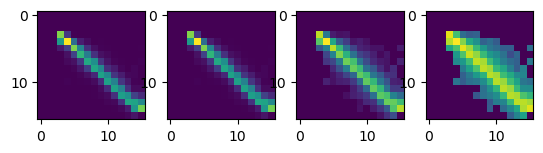

In [113]:
fig, axs = plt.subplots(1,4)

axs[0].imshow(mixing_matrix)
axs[1].imshow(mixing_matrix_dilation1)
axs[2].imshow(mixing_matrix_dilation2)
axs[3].imshow(mixing_matrix_dilation5)

plt.show()

In [115]:
def add_row_starts(mat, bins):
    """
    Adds required starts of rows to the mixing matrix mat, according to provided bins
    """
    final_mat = np.zeros(shape=(mat.shape[0], mat.shape[1]+1))
    for i in range(mat.shape[0]):
        final_mat[i] = np.concat([[bins[i]], mat[i,:]])
    return final_mat

In [116]:
married_matrix_natsal = add_row_starts(mixing_matrix, age_bins)

In [117]:
with np.printoptions(suppress=True):
    print(np.array2string(married_matrix_natsal, separator=', ', precision=3, max_line_width=1_000).replace("\n", ""))

[[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.565,  0.115,  0.004,  0.001,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.384,  0.698,  0.252,  0.059,  0.023,  0.002,  0.004,  0.001,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.051,  0.132,  0.562,  0.316,  0.096,  0.03 ,  0.007,  0.004,  0.002,  0.002,  0.   ,  0.   ,  0.004], [30.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.031,  0.137,  0.456,  0.29 ,  0.099,  0.03 ,  0.017,  0.005,  0.001,  0.003,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   , 

In [103]:
#Looking at the mixing matrix from https://doi.org/10.1016/j.epidem.2018.03.004
#potentially as general sexual mixing data this could accoutn for a casual layer and then the above for a married layer hmm. unless this is where sophie got her stuff from

casual_literature = [[	0,	0,	0,	0,	0,	        0,	0,	0,	0,	0,	0,	0],
                     [	0,	0,	0,	0,	0,	        0,	0,	0,	0,	0,	0,	0],  
                     [	0,	0,	0,	0,	0,	        0,	0,	0,	0,	0,	0,	0],  
                     [	0,	0,	0,	60.4,	58.9,	16,	3,	0.5,	0.1,	0,	0,	0],  
                       [0,	0,	0,	23.8,	71.1,	45.6,	17.2,	5.2,	1.4,	0.3,	0.1,	0], 
                           [	0,	0,	0,	3.2,	25.3,	34.6,	23.8,	11.5,	4.6,	1.7,	0.6,	0.2], 
                               [	0,	0,	0,	0.3,	5.9,	15.6,	18.6,	14.5,	8.3,	3.9,	1.6,	0.6],
                                       [	0,	0,	0,	0,	1.2,	    5.5,	10.2,	12.6,	11.1,	7.2,	3.6,	1.4],  
                                         [	0,	0,	0,	0,	0.2,	    1.6,	4.3,	7.7,	10.2,	9.9,	6.6,	3.1],  
                                           [	0,	0,	0,	0,	0,	        0.4,	1.5,	3.3,	6.1,	8.9,	9.2,	5.7],   
                                             [	0,	0,	0,	0,	0,	        0.1,	0.4,	1.1,	2.4,	4.8,	7.8,	8.2],  
                                                 [	0,	0,	0,	0,	0,	        0,	0.1,	0.3,	0.7,	1.6,	3.5,	6.5]]
casual_literature = np.array(casual_literature)
casual_literature = casual_literature / casual_literature.sum(axis=0, keepdims=True)
casual_literature = np.nan_to_num(casual_literature)


#Extend matrix to include 60,65,70,75 age bins (by filling with zeroes as sexual encounters at this age have negligable (likely no) impact on our modelled output, and besides can be expected to have relatively low occurance rate also)
casual_literature = np.pad(casual_literature, ((0, 4), (0, 4)), mode='constant')

casual_literature = add_row_starts(casual_literature, age_bins)

with np.printoptions(suppress=True):
    print(np.array2string(casual_literature, separator=', ', precision=3, max_line_width=1_000).replace("\n", ""))

[[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.689,  0.362,  0.134,  0.038,  0.009,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.271,  0.437,  0.382,  0.217,  0.092,  0.031,  0.008,  0.003,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.036,  0.156,  0.29 ,  0.301,  0.203,  0.102,  0.044,  0.018,  0.008,  0.   ,  0.   ,  0.   ,  0.   ], [30.   ,  0.   ,  0.   ,  0.   ,  0.003,  0.036,  0.131,  0.235,  0.256,  0.185,  0.102,  0.048,  0.023,  0.   ,  0.   ,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   , 

/var/folders/zv/s824tx9n4x7fz_rn2vwjt13w0000gs/T/ipykernel_67087/70435974.py:17: RuntimeWarning: invalid value encountered in divide
  casual_literature = casual_literature / casual_literature.sum(axis=0, keepdims=True)


In [118]:
married_matrix_s = [        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [10, 0, 0, 0.08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [15, 0, 0, 0.08, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],        [20, 0, 0, 0, 0, 0.6, 2, 0.2, 0.1, 0, 0, 0, 0, 0, 0, 0, 0],        [25, 0, 0, 0, 0, 0.6, 1, 2, 0.4, 0.1, 0, 0, 0, 0, 0, 0, 0],        [30, 0, 0, 0, 0, 0.5, 0.5, 2, 1, 0.5, 0.1, 0, 0, 0, 0, 0, 0],        [35, 0, 0, 0, 0, 1, 0.5, 1, 2, 1, 0.5, 0.2, 0, 0, 0, 0, 0],        [40, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0.5, 0.3, 0.1, 0, 0, 0, 0],        [45, 0, 0, 0, 0, 0.1, 1, 2, 2, 2, 1, 0.5, 0.2, 0.08, 0, 0, 0],        [50, 0, 0, 0, 0, 0, 0.1, 1, 2, 3, 2, 2, 0.5, 0.2, 0.05, 0, 0],        [55, 0, 0, 0, 0, 0, 0, 0.1, 1, 2, 3, 3, 2, 1, 0.3, 0.1, 0.1],        [60, 0, 0, 0, 0, 0, 0, 0.1, 0.5, 1, 2, 3, 3, 2, 0.5, 0.3, 0.1],        [65, 0, 0, 0, 0, 0, 0, 0, 0.5, 1, 2, 2, 3, 3, 2, 1, 0.2],        [70, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 1, 2, 3, 3, 2, 1],        [75, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 3],    ]
casual_matrix_s = [[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],        [5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],        [10,0,0,0,0.2,0.1,0.05,0,0,0,0,0,0,0,0,0,0],        [15,0,0,1,2,3,2,1,0.5,0,0,0,0,0,0,0,0],        [20,0,0,0.15,2,3,2,2,1,0.15,0,0,0,0,0,0,0],        [25,0,0,0.15,0.25,1,2,2,1,1,0,0,0,0,0,0,0],        [30,0,0,0,0,0.5,0.5,2,1,0.15,0,0,0,0,0,0,0],        [35,0,0,0,0,1,0.5,1,2,1,0.5,0,0,0,0,0,0],        [40,0,0,0,0,1,1,1,1,1,0.5,0.25,0,0,0,0,0],        [45,0,0,0,0,0.15,1,2,2,2,1,0.5,0.2,0.1,0,0,0],        [50,0,0,0,0,0,0.15,1,2,3,2,2,0.5,0.2,0.05,0,0],        [55,0,0,0,0,0,0,0.15,1,2,3,3,2,1,0.25,0.1,0.1],        [60,0,0,0,0,0,0,0.15,0.15,1,2,3,3,2,0.5,0.25,0.1],        [65,0,0,0,0,0,0,0,0,0,1,1,2,2,1,0.5,0],        [70,0,0,0,0,0,0,0,0,0,0,0,0,0.8,1,0.7,0.5],        [75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.1,0.25]    ]

married_matrix_natsal = [[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.565,  0.115,  0.004,  0.001,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.384,  0.698,  0.252,  0.059,  0.023,  0.002,  0.004,  0.001,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.051,  0.132,  0.562,  0.316,  0.096,  0.03 ,  0.007,  0.004,  0.002,  0.002,  0.   ,  0.   ,  0.004], [30.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.031,  0.137,  0.456,  0.29 ,  0.099,  0.03 ,  0.017,  0.005,  0.001,  0.003,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.018,  0.032,  0.112,  0.422,  0.349,  0.107,  0.038,  0.01 ,  0.004,  0.002,  0.   ,  0.007], [40.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.009,  0.042,  0.128,  0.412,  0.326,  0.095,  0.054,  0.011,  0.002,  0.011,  0.   ], [45.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.002,  0.009,  0.031,  0.078,  0.402,  0.331,  0.107,  0.057,  0.016,  0.013,  0.   ], [50.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.006,  0.002,  0.005,  0.007,  0.02 ,  0.089,  0.399,  0.309,  0.111,  0.047,  0.007,  0.004], [55.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.005,  0.021,  0.085,  0.402,  0.306,  0.098,  0.02 ,  0.02 ], [60.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.005,  0.01 ,  0.021,  0.093,  0.391,  0.349,  0.137,  0.086], [65.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.01 ,  0.014,  0.101,  0.417,  0.406,  0.33 ], [70.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.002,  0.   ,  0.004,  0.016,  0.054,  0.365,  0.549], [75.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.002,  0.013,  0.041,  0.   ]]
casual_literature = [[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [ 5.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [10.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [15.   ,  0.   ,  0.   ,  0.   ,  0.689,  0.362,  0.134,  0.038,  0.009,  0.002,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [20.   ,  0.   ,  0.   ,  0.   ,  0.271,  0.437,  0.382,  0.217,  0.092,  0.031,  0.008,  0.003,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [25.   ,  0.   ,  0.   ,  0.   ,  0.036,  0.156,  0.29 ,  0.301,  0.203,  0.102,  0.044,  0.018,  0.008,  0.   ,  0.   ,  0.   ,  0.   ], [30.   ,  0.   ,  0.   ,  0.   ,  0.003,  0.036,  0.131,  0.235,  0.256,  0.185,  0.102,  0.048,  0.023,  0.   ,  0.   ,  0.   ,  0.   ], [35.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.007,  0.046,  0.129,  0.222,  0.247,  0.188,  0.109,  0.054,  0.   ,  0.   ,  0.   ,  0.   ], [40.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.013,  0.054,  0.136,  0.227,  0.258,  0.2  ,  0.121,  0.   ,  0.   ,  0.   ,  0.   ], [45.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.003,  0.019,  0.058,  0.136,  0.232,  0.279,  0.222,  0.   ,  0.   ,  0.   ,  0.   ], [50.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.005,  0.019,  0.053,  0.125,  0.236,  0.319,  0.   ,  0.   ,  0.   ,  0.   ], [55.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.001,  0.005,  0.016,  0.042,  0.106,  0.253,  0.   ,  0.   ,  0.   ,  0.   ], [60.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [65.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [70.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ], [75.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ]]


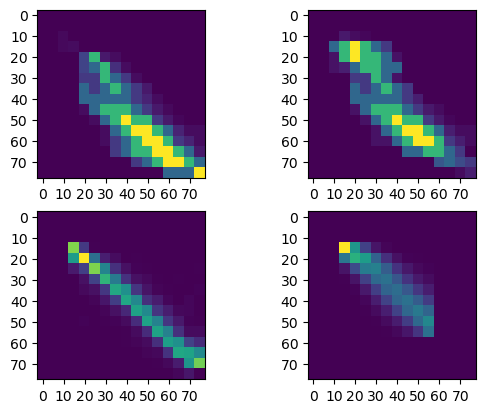

In [119]:
fig, axs = plt.subplots(2,2)

axs[0,0].imshow(np.array(married_matrix_s)[:,1:])
axs[0,1].imshow(np.array(casual_matrix_s)[:,1:])
axs[1,0].imshow(np.array(married_matrix_natsal)[:,1:])
axs[1,1].imshow(np.array(casual_literature)[:,1:])

for i in range(2):
    for j in range(2):
        axs[i,j].set_xticks([0,2,4,6,8,10,12,14],[0,10,20,30,40,50,60,70])
        axs[i,j].set_yticks([0,2,4,6,8,10,12,14],[0,10,20,30,40,50,60,70])



plt.show()

# Find debut distributions

In [3]:
#Extract raw data
males = df[df['rsex']==1]
females = df[df['rsex']==2]

debuts_m = males[males['afsexall']<96]['afsexall'] #for simplicity, filter out all cases where answer is 'not happened yet' or 'refused'/'not answered'
debuts_f = females[females['afsexall']<96]['afsexall']



debuts_m = debuts_m[debuts_m>10] #filter out debuts <=10 from our modelling for taking logs and avoiding likely erroneous data
debuts_f = debuts_f[debuts_f>10]




<scipy.stats._continuous_distns.exponnorm_gen object at 0x15f909010>: (np.float64(2.0408916163272464), np.float64(14.86159360812454), np.float64(1.2446420329339398))
<scipy.stats._continuous_distns.alpha_gen object at 0x14f653770>: (np.float64(5.618387159312963), np.float64(3.203780507580624), np.float64(76.98433520115125))
<scipy.stats._continuous_distns.norm_gen object at 0x14f653620>: (np.float64(17.40177918596149), np.float64(2.9399368387978195))
<scipy.stats._continuous_distns.lognorm_gen object at 0x15faa8d70>: (np.float64(0.32524556671986043), 9.12174661160612, np.float64(7.841656969362918))
<scipy.stats._continuous_distns.expon_gen object at 0x15f908ec0>: (11.0, 6.401779185961491)
<scipy.stats._continuous_distns.gamma_gen object at 0x15f90a510>: (np.float64(0.8076121526604536), np.float64(10.999999999999998), np.float64(2.3053414919370603))
exponnorm: AIC=38277.87
alpha: AIC=38479.63
lognorm: AIC=38659.77
norm: AIC=40990.12
expon: AIC=46886.12
gamma: AIC=64373.73


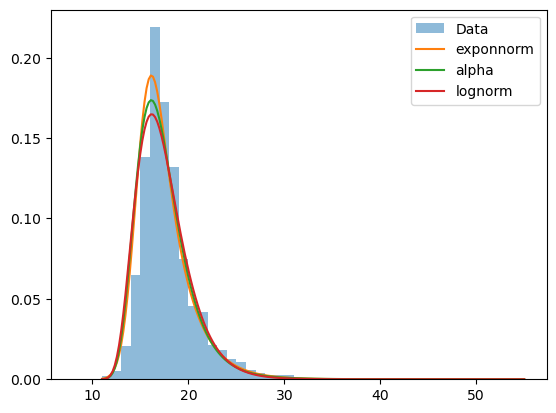

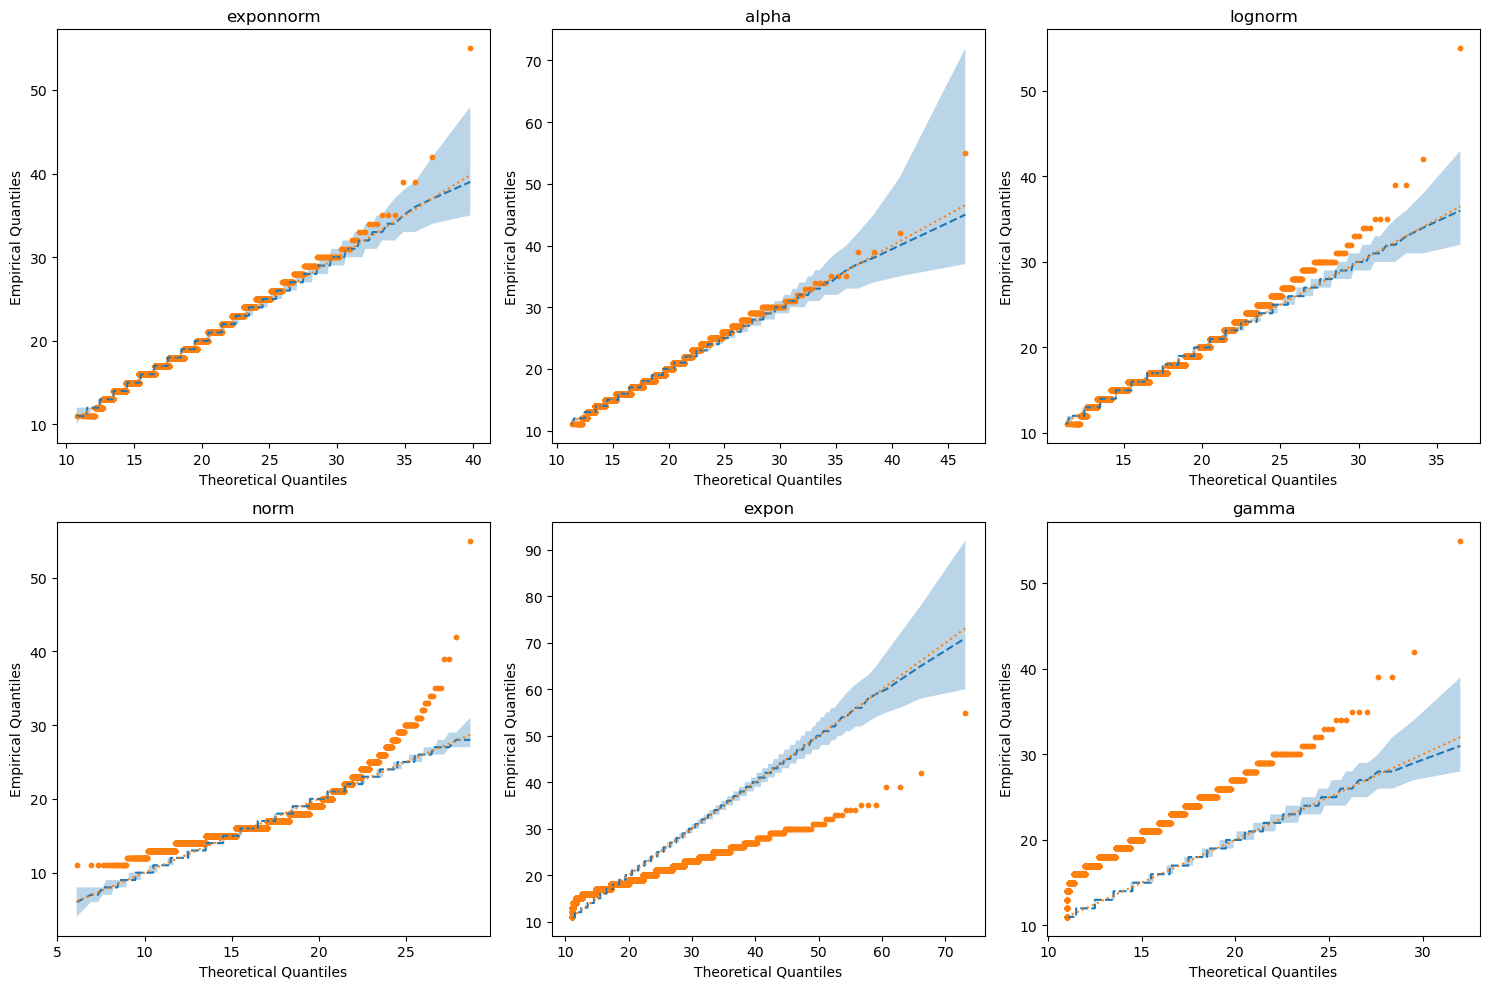

In [ ]:
#Fit data for FEMALE

distributions = [
    stats.exponnorm,
    stats.alpha,
    stats.norm,
    stats.lognorm,
    stats.expon,
    stats.gamma,
]

data = debuts_f

distributions = distributions

results = []

for dist in distributions:
    try:
        # Fit distribution
        params = dist.fit(data)
        print(f'{dist}: {params}')

        # Log-likelihood
        loglik = np.sum(dist.logpdf(data, *params))

        # Number of parameters
        k = len(params)

        # AIC (Akaike Information Criterion)
        aic = 2 * k - 2 * loglik

        results.append((dist.name, aic, params))
    except Exception as e:
        print(f"{dist.name} failed: {e}")

# Sort by AIC (lower is better)
results.sort(key=lambda x: x[1])

for name, aic, params in results:
    print(f"{name}: AIC={aic:.2f}")


#Histogram
x = np.linspace(min(data), max(data), 200)

plt.hist(data, bins=np.arange(8,40,1), density=True, alpha=0.5, label="Data")

for name, _, params in results[:3]:  
    dist = getattr(stats, name)
    plt.plot(x, dist.pdf(x, *params), label=name)

plt.legend()
plt.show()

# ---- QQ plot with simulation bands ----
n_sim = 10_000  # increase for smoother bands
data = debuts_f
n=len(data)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1], axes[1,2]]

for ax, (name, _, params) in zip(axes, results[:6]):
    dist = getattr(stats, name)

    sorted_data = np.sort(data)
    probs = (np.arange(1, n+1) - 0.5) / n

    # Theoretical quantiles
    theoretical_q = dist.ppf(probs, *params)

    # --- Simulate envelopes ---
    sim_quantiles = np.zeros((n_sim, n))

    for i in range(n_sim):
        sim_sample = dist.rvs(*params, size=n)
        sim_sample = np.round(sim_sample)
        sim_quantiles[i, :] = np.sort(sim_sample)

    lower = np.percentile(sim_quantiles, 2.5, axis=0)
    upper = np.percentile(sim_quantiles, 97.5, axis=0)
    median = np.percentile(sim_quantiles, 50, axis=0)

    # --- Plot ---
    ax.fill_between(theoretical_q, lower, upper, alpha=0.3)
    ax.plot(theoretical_q, median, linestyle='--')
    ax.scatter(theoretical_q, sorted_data, s=10)

    # 45-degree reference
    ax.plot(theoretical_q, theoretical_q, linestyle=':')

    ax.set_title(name)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")

plt.tight_layout()
plt.show()


<scipy.stats._continuous_distns.exponnorm_gen object at 0x15f909010>: (np.float64(1.7915590056501285), np.float64(14.599511148535075), np.float64(1.4554358347246472))
<scipy.stats._continuous_distns.alpha_gen object at 0x14f653770>: (np.float64(5.820413155751893), np.float64(1.381598872288413), np.float64(89.09293081903846))
<scipy.stats._continuous_distns.norm_gen object at 0x14f653620>: (np.float64(17.207018162581555), np.float64(3.2112744615303823))
<scipy.stats._continuous_distns.lognorm_gen object at 0x15faa8d70>: (np.float64(0.3249923622647172), 8.281760878550369, np.float64(8.4520657241918))
<scipy.stats._continuous_distns.expon_gen object at 0x15f908ec0>: (11.0, 6.207018162581555)
<scipy.stats._continuous_distns.gamma_gen object at 0x15f90a510>: (np.float64(5.991726094429984), np.float64(9.96212315414372), np.float64(1.2091498215271481))
exponnorm: AIC=27308.65
alpha: AIC=27424.09
lognorm: AIC=27560.21
gamma: AIC=27749.07
norm: AIC=29329.95
expon: AIC=32052.87


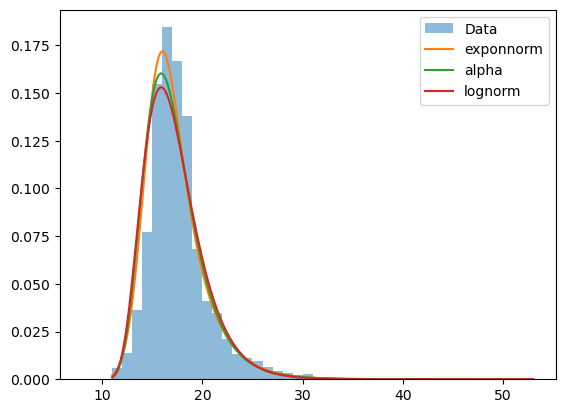

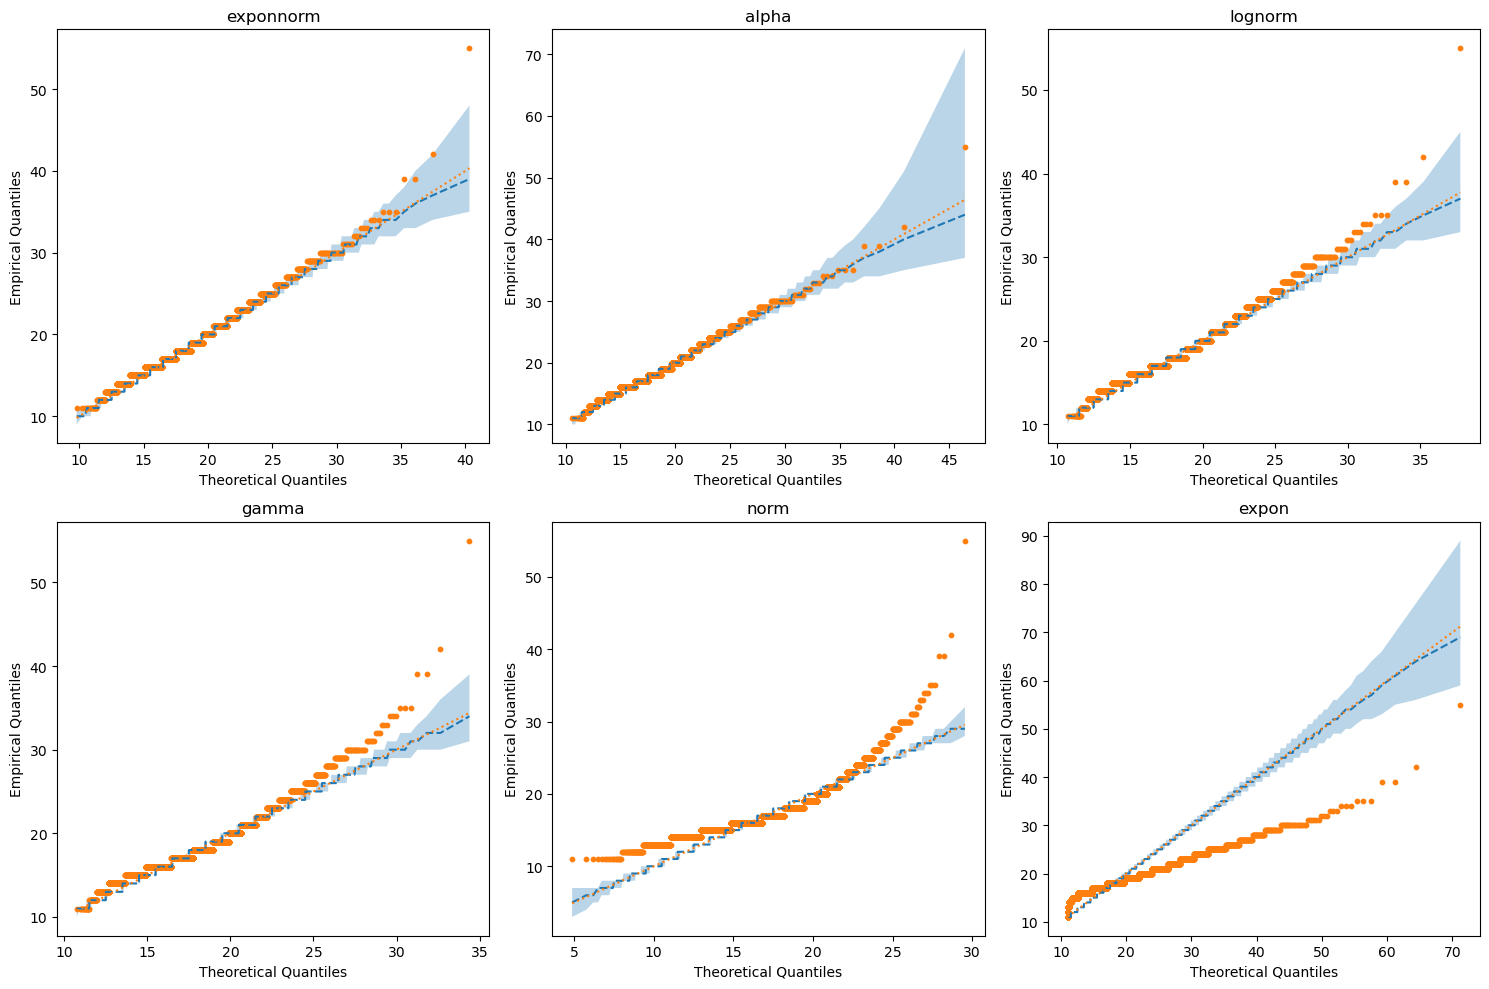

In [ ]:
#Fit data for MALE

distributions = [
    stats.exponnorm,
    stats.alpha,
    stats.norm,
    stats.lognorm,
    stats.expon,
    stats.gamma,
]

data = debuts_m

distributions = distributions 

results = []

for dist in distributions:
    try:
        # Fit distribution
        params = dist.fit(data)
        print(f'{dist}: {params}')

        # Log-likelihood
        loglik = np.sum(dist.logpdf(data, *params))

        # Number of parameters
        k = len(params)

        # AIC (Akaike Information Criterion)
        aic = 2 * k - 2 * loglik

        results.append((dist.name, aic, params))
    except Exception as e:
        print(f"{dist.name} failed: {e}")

# Sort by AIC (lower is better)
results.sort(key=lambda x: x[1])

for name, aic, params in results:
    print(f"{name}: AIC={aic:.2f}")


#Histogram
x = np.linspace(min(data), max(data), 200)

plt.hist(data, bins=np.arange(8,40,1), density=True, alpha=0.5, label="Data")

for name, _, params in results[:3]:  # top 3
    dist = getattr(stats, name)
    plt.plot(x, dist.pdf(x, *params), label=name)

plt.legend()
plt.show()

# ---- QQ plot with simulation bands ----
n_sim = 10_000  # increase for smoother bands
data = debuts_f
n=len(data)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1], axes[1,2]]

for ax, (name, _, params) in zip(axes, results[:6]):
    dist = getattr(stats, name)

    sorted_data = np.sort(data)
    probs = (np.arange(1, n+1) - 0.5) / n

    # Theoretical quantiles
    theoretical_q = dist.ppf(probs, *params)

    # --- Simulate envelopes ---
    sim_quantiles = np.zeros((n_sim, n))

    for i in range(n_sim):
        sim_sample = dist.rvs(*params, size=n)
        sim_sample = np.round(sim_sample)
        sim_quantiles[i, :] = np.sort(sim_sample)

    lower = np.percentile(sim_quantiles, 2.5, axis=0)
    upper = np.percentile(sim_quantiles, 97.5, axis=0)
    median = np.percentile(sim_quantiles, 50, axis=0)

    # --- Plot ---
    ax.fill_between(theoretical_q, lower, upper, alpha=0.3)
    ax.plot(theoretical_q, median, linestyle='--')
    ax.scatter(theoretical_q, sorted_data, s=10)

    # 45-degree reference
    ax.plot(theoretical_q, theoretical_q, linestyle=':')

    ax.set_title(name)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")

plt.tight_layout()
plt.show()
